In [61]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import precision_recall_curve


In [3]:
url = 'https://raw.githubusercontent.com/Rocio7531/telco-churn-analysis/main/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# DATA QUALITY CHECKS

df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [8]:
# TotalCharges is an object when this should be a number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Checking missing values
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [10]:
# I have 11 NaNs in 7043 rows --> 11/7043 = 0.15% --> because it represents less than 1% of the dataset, I decided to removed them.
df.dropna(inplace=True)

In [12]:
print(df.isnull().sum())

df['Churn'].value_counts()

#Missing values were handled appropriately
#The dataset is imbalanced

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,count
Churn,
No,5163
Yes,1869


In [13]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

# EXPLORATORY DATA ANALYSIS (EDA)
**CATEGORICAL FEATURES VS CHURN**

In [16]:
pd.crosstab(df['Partner'], df['Churn'], normalize='index')
# Customers without a partner show a higher churn rate

Churn,No,Yes
Partner,,
No,0.670239,0.329761
Yes,0.802829,0.197171


In [17]:
pd.crosstab(df['Dependents'], df['Churn'], normalize='index')
# Customers without dependents are more likely to churn

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.844688,0.155312


In [18]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
# Customers classified as senior citizens show a higher churn rate compared to non-senior customers

Churn,No,Yes
SeniorCitizen,,
0,0.763497,0.236503
1,0.583187,0.416813


In [19]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')
# Contract type shows a strong relationship with churn,
# with month-to-month customers having significantly higher churn rates

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


In [20]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')
# Customers using electronic check show a higher churn rate compared to other payment methods

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


In [21]:
pd.crosstab(df['PhoneService'], df['Churn'], normalize='index')
# Phone service does not appear to have a strong impact on churn

Churn,No,Yes
PhoneService,,
No,0.750000,0.250000
Yes,0.732525,0.267475


In [22]:
pd.crosstab(df['MultipleLines'], df['Churn'], normalize='index')
# Multiple lines have a slight association with higher churn, but the effect is weak

Churn,No,Yes
MultipleLines,,
No,0.749188,0.250812
No phone service,0.750000,0.250000
Yes,0.713515,0.286485


In [23]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
# InternetService shows a strong relationship with churn,
# with fiber optic customers having significantly higher churn rates
# This may indicate higher expectations or pricing issues among fiber optic customers

Churn,No,Yes
InternetService,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


In [24]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index')
# Customers without Online Security are more likely to churn

Churn,No,Yes
OnlineSecurity,,
No,0.582213,0.417787
No internet service,0.925658,0.074342
Yes,0.853598,0.146402


In [25]:
pd.crosstab(df['OnlineBackup'], df['Churn'], normalize='index')
# Customers without online backup are more likely to churn

Churn,No,Yes
OnlineBackup,,
No,0.600583,0.399417
No internet service,0.925658,0.074342
Yes,0.784330,0.215670


In [26]:
pd.crosstab(df['DeviceProtection'], df['Churn'], normalize='index')
# Customers without device protection show a higher churn rate

Churn,No,Yes
DeviceProtection,,
No,0.608597,0.391403
No internet service,0.925658,0.074342
Yes,0.774607,0.225393


In [27]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')
# Lack of tech support is strongly associated with higher churn

Churn,No,Yes
TechSupport,,
No,0.583525,0.416475
No internet service,0.925658,0.074342
Yes,0.848039,0.151961


In [28]:
pd.crosstab(df['StreamingTV'], df['Churn'], normalize='index')
# StreamingTV shows a weak relationship with churn

Churn,No,Yes
StreamingTV,,
No,0.664649,0.335351
No internet service,0.925658,0.074342
Yes,0.698853,0.301147


In [29]:
pd.crosstab(df['StreamingMovies'], df['Churn'], normalize='index')
# StreamingMovies does not appear to be a strong driver of churn

Churn,No,Yes
StreamingMovies,,
No,0.662711,0.337289
No internet service,0.925658,0.074342
Yes,0.700476,0.299524


Summary of Categorical EDA Insights

The categorical analysis shows that some customer attributes have a much stronger relationship with churn than others.

- **Contract type** is one of the strongest churn drivers. Customers with month-to-month contracts show significantly higher churn rates than customers with one-year or two-year contracts.

- **Payment method** also shows a clear relationship with churn. Customers using electronic check have a higher churn rate compared to other payment methods.

- **Internet service type** is strongly associated with churn. Fiber optic customers show considerably higher churn rates than DSL customers or customers without internet service.

- **Additional services** appear to play an important role in customer retention. Customers without OnlineSecurity, TechSupport, OnlineBackup, or DeviceProtection tend to show higher churn rates.

- Some variables, such as PhoneService, MultipleLines, StreamingTV, and StreamingMovies, show weaker differences between groups and do not appear to be strong churn drivers on their own.

Overall, categorical features suggest that churn is mainly associated with flexible contracts, electronic payment methods, fiber optic internet service, and the lack of additional support/security services.

**NUMERICAL FEATURES VS CHURN**

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

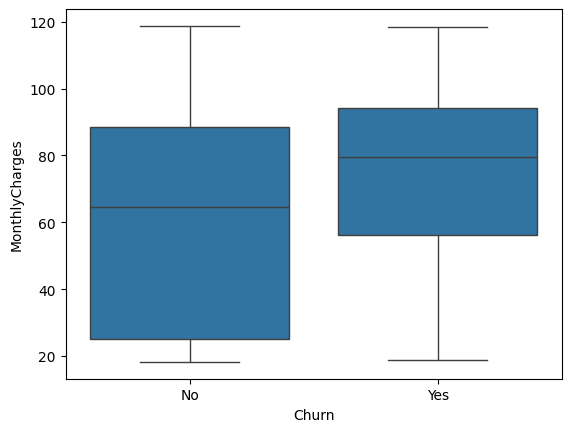

In [31]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

# Customers who churn tend to have higher monthly charges on average

# the overlap indicates that it is not possible to define a clear threshold
# (e.g., "above X → churn"), since many customers in the same price range do not churn.

# Therefore, MonthlyCharges alone is not sufficient to clearly separate the classes.

# MonthlyCharges shows a weaker and less discriminative effect due to overlap between groups

<Axes: xlabel='Churn', ylabel='tenure'>

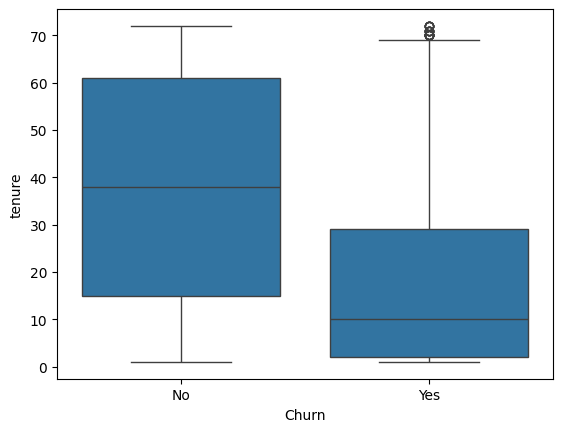

In [32]:
sns.boxplot(x='Churn', y='tenure', data=df)

# Customers who churn have a significantly lower tenure (median ≈ 10 months)
# compared to non-churn customers (median ≈ 38 months).

# This suggests that newer customers are much more likely to churn,
# although churn is not exclusive to them.

# The distributions are relatively well separated,
# indicating that tenure is a strong predictor of churn,
# especially compared to variables like MonthlyCharges.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

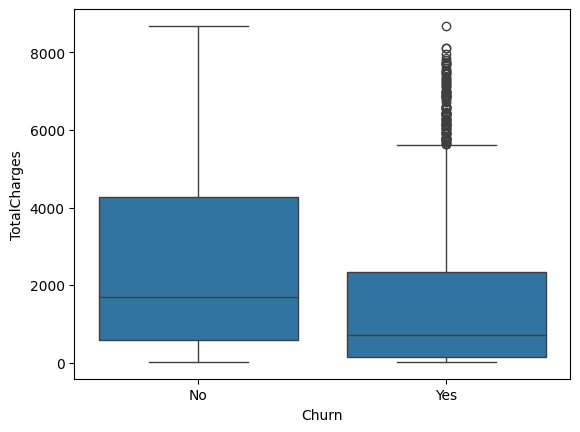

In [33]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

# Customers who churn tend to have lower TotalCharges on average,
# indicating that they have not stayed long enough to accumulate high total spending.

# While there are some high-value outliers among churned customers,
# the overall distribution shows that non-churn customers have significantly higher total charges.

# This suggests that churn is more common among newer customers.


Summary of Numerical EDA Insights

The numerical analysis shows that some customer attributes have a much stronger relationship with churn than others.

**MonthlyCharges**:
Customers who churn tend to have higher monthly charges on average. However, there is significant overlap between churn and non-churn groups, indicating that MonthlyCharges alone is not a strong discriminator.

**Tenure**:
Tenure shows a strong relationship with churn. Customers who churn typically have much lower tenure, suggesting that churn is more common among newer customers.

**TotalCharges**:
Customers who churn tend to have lower TotalCharges on average, which indicates they have not remained long enough to accumulate high total spending. While some churned customers have high TotalCharges, they are outliers and do not represent the overall trend.

**Combined insight:**
TotalCharges is closely related to both tenure and MonthlyCharges (TotalCharges ≈ tenure × MonthlyCharges). The observed patterns suggest that tenure is the primary driver behind churn, with TotalCharges reinforcing this effect. In other words, customers are more likely to churn early in their lifecycle, before generating significant total revenue.

This highlights the importance of early-stage customer retention strategies.

#Data Preprocessing & Feature Engineering

In [36]:
categorical_cols = [
    'gender','Partner','Dependents','PhoneService','MultipleLines',
    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'
]

numerical_cols = ['tenure','MonthlyCharges','TotalCharges']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [38]:
df.drop('customerID', axis=1, inplace=True)

In [41]:
X = df.drop('Churn', axis=1)
y = df['Churn']

y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=123, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123, stratify=y_temp)

In [42]:
pipelines = {
  'DecisionTree': Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', DecisionTreeClassifier(random_state=123, class_weight='balanced'))
  ]),
  'RandomForest': Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=123, class_weight='balanced'))
  ]),
  'XGBoost': Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=123, scale_pos_weight=996/441, eval_metric='logloss'))
  ])
}
# Setting scale_pos_weight = 996/441 adjusts for class imbalance by assigning
# higher importance to the minority class ("Yes").
# This encourages the model to better identify churn cases, improving recall.

In [43]:
param_grids = {
    'DecisionTree': {
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 10, 20],
        'classifier__min_samples_leaf': [1, 5, 10]
    },
    'RandomForest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 10],
        'classifier__min_samples_leaf': [1, 5]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__subsample': [0.8, 1.0]
    }
}

In [46]:
results = []
best_estimators = {}

for name, pipeline in pipelines.items():
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    results.append({
        'model': name,
        'best_cv_f1': grid.best_score_,
        'best_params': grid.best_params_
    })

    best_estimators[name] = grid.best_estimator_

results_df = pd.DataFrame(results).sort_values('best_cv_f1', ascending=False)
print(results_df)

# best_estimator_ returns the model already fitted with the best-performing set of hyperparameters.

          model  best_cv_f1                                        best_params
1  RandomForest    0.632474  {'classifier__max_depth': 10, 'classifier__min...
2       XGBoost    0.632153  {'classifier__learning_rate': 0.01, 'classifie...
0  DecisionTree    0.610346  {'classifier__max_depth': 5, 'classifier__min_...


In [47]:
# Choosing between RandomForest and XGBoost

rf_best = best_estimators['RandomForest']
xgb_best = best_estimators['XGBoost']

for name, model in [('RF', rf_best), ('XGB', xgb_best)]:
    y_val_proba = model.predict_proba(X_val)[:, 1]
    print(f"\nModel: {name}")
    for t in [0.5, 0.4, 0.3]:
        preds = (y_val_proba >= t).astype(int)
        print(f"Threshold {t}")
        print(classification_report(y_val, preds))


# Lowering the decision threshold from 0.5 to 0.3 increases churn detection (higher recall),
# at the cost of more false positives (lower precision).
# In churn prediction, this trade-off is acceptable since missing a leaving customer
# is more costly than incorrectly flagging a retained one.


Modelo: RF
Threshold 0.5
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1032
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1406
   macro avg       0.71      0.75      0.72      1406
weighted avg       0.79      0.76      0.77      1406

Threshold 0.4
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1032
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1406
   macro avg       0.71      0.76      0.71      1406
weighted avg       0.80      0.73      0.75      1406

Threshold 0.3
              precision    recall  f1-score   support

           0       0.94      0.63      0.75      1032
           1       0.46      0.89      0.61       374

    accuracy                           0.70      1406
   macro avg       0.70      0.76      0.68      1406
weighted avg       0

Interpretation:

* XGBoost achieves higher recall for churn detection, whereas Random Forest provides a more balanced performance (higher F1-score).

* Given that the primary goal is to minimize missed churn cases, XGBoost is chosen as the final model.

* Although accuracy drops to 0.64 after lowering the decision threshold, recall for churn improves significantly to 0.93, which better aligns with the business objective.

In [49]:
# Choosing the best model

best_model_name = 'XGBoost'
best_model = best_estimators[best_model_name]

print("Best model:", best_model_name)
print("Best params:", results_df[results_df['model'] == best_model_name]['best_params'].values[0])

Best model: XGBoost
Best params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


              precision    recall  f1-score   support

           0       0.94      0.56      0.70      1033
           1       0.43      0.90      0.58       374

    accuracy                           0.65      1407
   macro avg       0.68      0.73      0.64      1407
weighted avg       0.80      0.65      0.67      1407



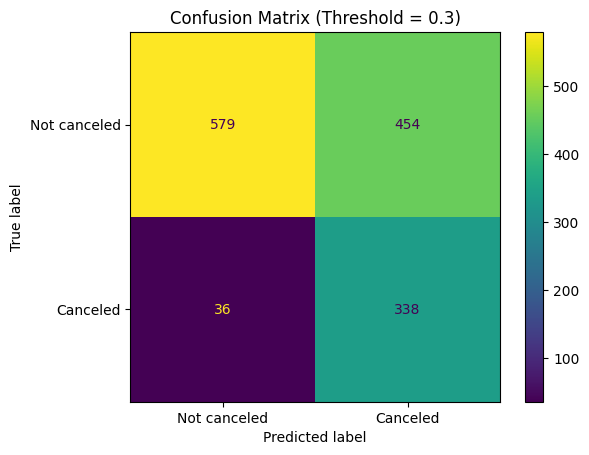

In [53]:
# Final evaluation

final_threshold = 0.3

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= final_threshold).astype(int)

print(classification_report(y_test, y_test_pred))

# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Not canceled', 'Canceled']
)
plt.title("Confusion Matrix (Threshold = 0.3)")
plt.show()

Several models were evaluated through cross-validation and hyperparameter tuning.
The decision threshold was then optimized on a validation set, prioritizing recall for the churn class.

The final model selected was XGBoost, with a threshold of 0.3, in order to maximize the detection of customers at risk of churn.
The model was then evaluated on the test set to assess its performance on unseen data.

In [54]:
# Display the names of the transformed features
best_model.named_steps['preprocessor'].get_feature_names_out()

array(['cat__gender_Female', 'cat__gender_Male', 'cat__Partner_No',
       'cat__Partner_Yes', 'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__StreamingTV_Yes', 'cat__StreamingMovies_No',
       'cat__StreamingMovies_No internet se

In [55]:
# Feature importance
# We can extract it using: model.named_steps['classifier'].feature_importances_
# Since OneHotEncoder modifies the original feature names, we first retrieve
# the transformed feature names from the preprocessor:

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['classifier'].feature_importances_

In [56]:
# To display feature importance:

feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances.sort_values('importance', ascending=False, inplace=True)
feature_importances.head(10)

# PRO INSIGHT:
# If Contract = Month-to-month → high churn

# 1. OneHotEncoder splits categorical features into multiple binary variables
# 2. XGBoost prioritizes clear decision rules
# 3. Correlated variables tend to lose importance

,feature,importance
32,cat__Contract_Month-to-month,0.418163
12,cat__InternetService_Fiber optic,0.082536
14,cat__OnlineSecurity_No,0.060329
34,cat__Contract_Two year,0.045481
39,num__tenure,0.039119
23,cat__TechSupport_No,0.038797
37,cat__PaymentMethod_Electronic check,0.030977
31,cat__StreamingMovies_Yes,0.026180
40,num__MonthlyCharges,0.025885
41,num__TotalCharges,0.024210


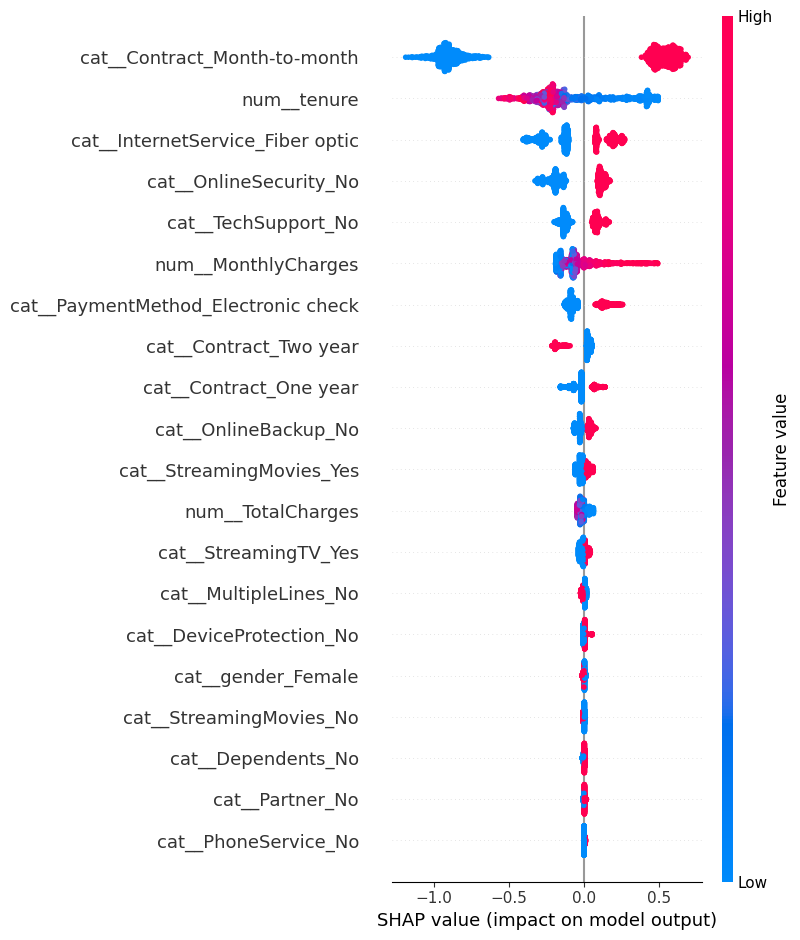

In [59]:
explainer = shap.Explainer(best_model.named_steps['classifier'])

X_transformed = best_model.named_steps['preprocessor'].transform(X_test)

shap_values = explainer(X_transformed)

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

# SHAP values computed on test data to explain model predictions

According to the SHAP plot:

- Contract_Month-to-month is the most influential feature:
  Customers with month-to-month contracts significantly increase the probability of churn,
  while long-term contracts reduce churn.

- Tenure:
  Low values (short tenure) are associated with higher churn, meaning newer customers are more likely to leave.
  High values (long tenure) reduce the probability of churn.

- InternetService_Fiber optic:
  Having fiber optic service increases churn,
  while not having it decreases churn.

- OnlineSecurity_No and TechSupport_No:
  Not having these services increases churn.
  Additional services act as retention mechanisms.

- MonthlyCharges:
  Higher monthly charges increase the probability of churn,
  while lower charges reduce it.

- TotalCharges:
  Lower importance due to its correlation with tenure and MonthlyCharges.

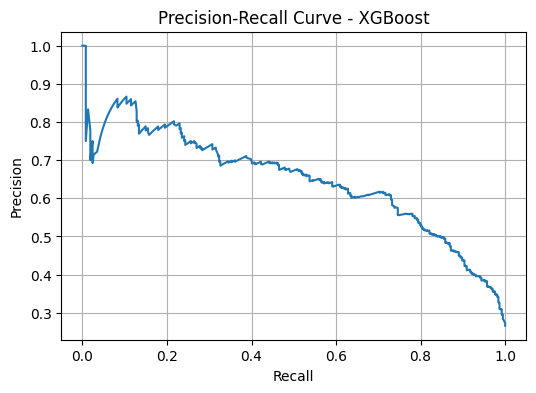

In [62]:
# Churn probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.grid()
plt.show()

# The curve shows the trade-off between precision and recall across all possible thresholds.
# Each point corresponds to a different threshold (not explicitly shown).
# This curve is used as a final visual evaluation. The decision threshold was previously selected using the validation set.

# Final Conclusion - Churn Analysis

**Objective:**  
The objective of this project was to analyze the key factors influencing customer churn and to develop a predictive model capable of identifying customers at high risk of leaving.

**Key findings (EDA + SHAP):**

- **Contract (Month-to-month)** is the strongest driver of churn.  
  Customers with month-to-month contracts show a significantly higher probability of churn, while long-term contracts reduce churn.

- **Tenure:**  
  Customers with low tenure are much more likely to churn, indicating that churn is more common in the early stages of the customer lifecycle.

- **Additional services:**  
  The absence of services such as OnlineSecurity and TechSupport is strongly associated with higher churn, suggesting that these services act as retention mechanisms.

- **InternetService (Fiber optic):**  
  Customers with fiber optic service exhibit higher churn, possibly due to higher costs or unmet expectations.

- **MonthlyCharges:**  
  Higher monthly charges are associated with increased churn; however, this variable shows significant overlap between classes, making it a weaker standalone predictor.

- **TotalCharges:**  
  Lower total charges are associated with churn, reinforcing the idea that customers tend to leave before generating significant cumulative value.  
  This relationship is closely linked to tenure (TotalCharges ≈ tenure × MonthlyCharges).

---

**Modeling:**

Several models (Decision Tree, Random Forest, and XGBoost) were evaluated using cross-validation and hyperparameter tuning.  
Although Random Forest achieved a higher F1-score, XGBoost was selected due to its superior recall on the validation set, aligning better with the business objective.

---

**Threshold Optimization:**

The decision threshold was reduced from 0.5 to 0.3 to prioritize recall.

This adjustment was made based on the business objective, where the cost of failing to detect churn is higher than generating false positives.

**Impact:**
- Churn recall increased from ~0.76 to ~0.93  
- Significant improvement in the detection of customers at risk  
- Increase in false positives (expected trade-off with lower precision)

This approach allows for identifying more customers at risk, at the cost of reduced precision.

---

**Final Performance:**

- Accuracy ≈ 0.64  
- Recall (churn) ≈ 0.93  
- The model prioritizes recall over precision, achieving a high ability to detect churn cases.

---

**Business Implications:**

- Focus retention efforts on new customers  
- Encourage long-term contracts  
- Promote additional services (e.g., security and support)  
- Review pricing strategies  
- Investigate customer experience in fiber optic services  

---

**Conclusion:**

The model effectively identifies customers at risk of churn and provides actionable insights that can support the design of targeted retention strategies.